In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Academic visualization configuration for inline display in Jupyter
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 120,    # Notebook inline display resolution
    'savefig.dpi': 300,   # Export image resolution
    'savefig.bbox': 'tight',
    'axes.axisbelow': True 
})

# Text box styling and Color Palette
text_bbox = dict(facecolor='white', edgecolor='none', alpha=0.9, pad=1.5)
COLORS = {
    'old': '#8c8c8c',      # Neutral grey for Baseline / Previous setup
    'new': '#2ca02c',      # Green for Proposed / New architecture
    'danger': '#d62728',   # Red for Non-stationary / Ablated models
    'safe': '#1f77b4',     # Blue for Stationary / Full models
}

# 2. Path configuration (Adjust project_root if running from a different directory)
project_root = Path("C:/Users/huy/Documents/GreenWich/COMP1682.1_FinalProject/Project")
results_dir = project_root / "results"
viz_dir = results_dir / "figures"
viz_dir.mkdir(parents=True, exist_ok=True)

# 3. Utility helper functions
def load_json(filename):
    filepath = results_dir / filename
    if not filepath.exists():
        print(f"Warning: Missing {filename}. Skipping...")
        return None
    with open(filepath, 'r') as f:
        return json.load(f)

def despine(ax):
    """Remove top and right spines from the plot."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

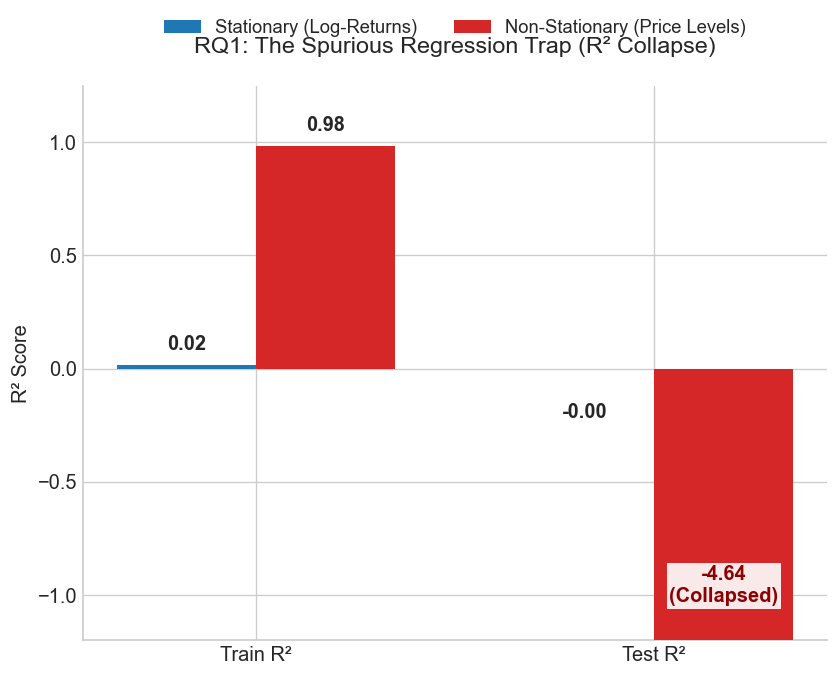

In [2]:
data = load_json("rq1_stationarity_results.json")
if data:
    categories = ['Train R²', 'Test R²']
    returns_r2 = [data["Stationary_Returns"]["Train"]["R2"], data["Stationary_Returns"]["Test"]["R2"]]
    prices_r2 = [data["NonStationary_Prices"]["Train"]["R2"], data["NonStationary_Prices"]["Test"]["R2"]]
    
    x = np.arange(len(categories))
    width = 0.35
    
    fig, ax1 = plt.subplots(figsize=(8, 6))
    
    rects1 = ax1.bar(x - width/2, returns_r2, width, label='Stationary (Log-Returns)', color=COLORS['safe'], zorder=3)
    rects2 = ax1.bar(x + width/2, prices_r2, width, label='Non-Stationary (Price Levels)', color=COLORS['danger'], zorder=3)
    
    ax1.set_ylabel('R² Score')
    ax1.set_title('RQ1: The Spurious Regression Trap (R² Collapse)', pad=20)
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories)
    ax1.set_ylim(-1.2, 1.25) 
    
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)
    despine(ax1)
    
    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            if height < -1.0:
                ax1.text(rect.get_x() + rect.get_width()/2, -1.05, 
                         f'{height:.2f}\n(Collapsed)', ha='center', va='bottom', 
                         fontweight='bold', color='darkred', bbox=text_bbox)
            else:
                offset = 0.05 if height >= 0 else -0.15
                va = 'bottom' if height >= 0 else 'top'
                ax1.text(rect.get_x() + rect.get_width()/2, height + offset, 
                         f'{height:.2f}', ha='center', va=va, fontweight='bold', bbox=text_bbox)
            
    plt.savefig(viz_dir / "rq1_spurious_regression_clean.png")
    plt.show()  # Display inline in Jupyter

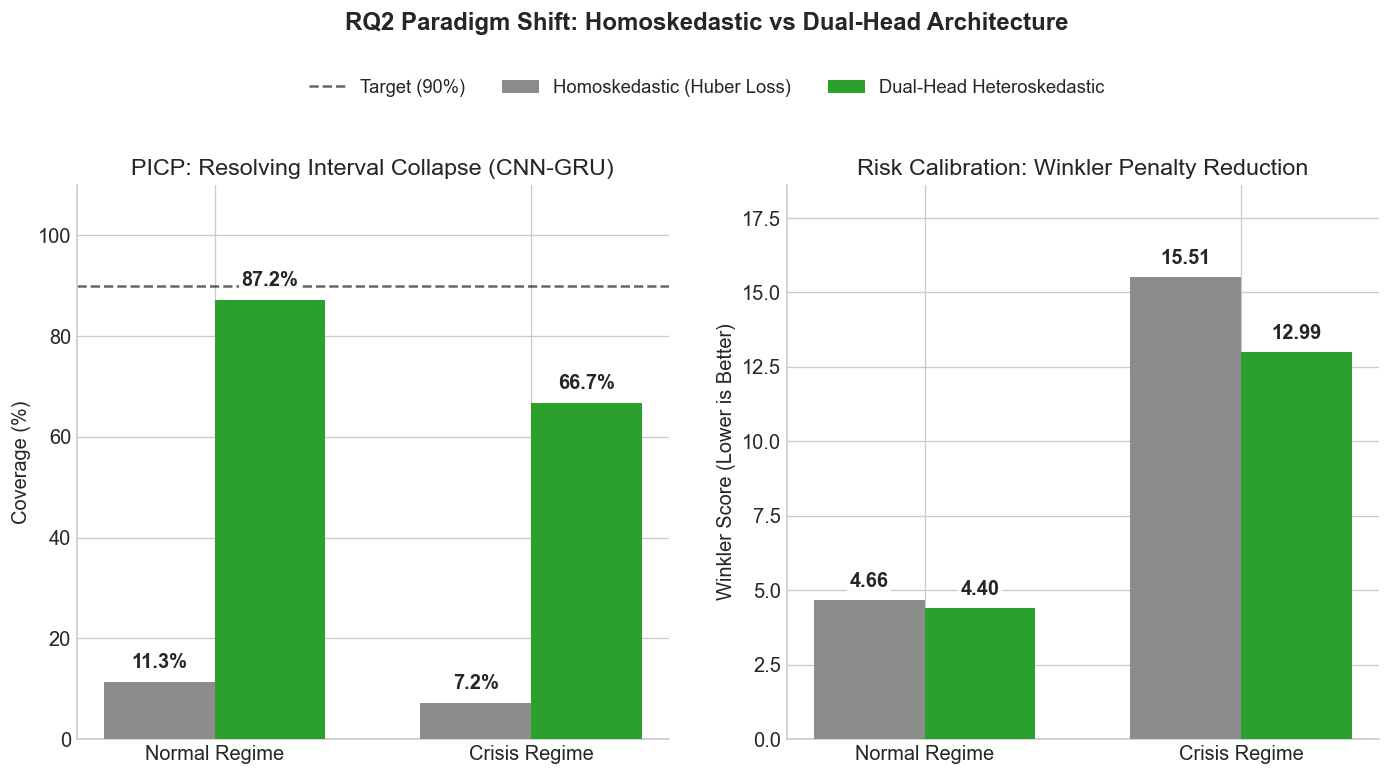

In [3]:
old_data = load_json("rq2_uncertainty_results_old.json")
new_data = load_json("rq2_uncertainty_results_2.json")

if old_data and new_data:
    old_cnn = old_data["CNN_GRU"]
    new_cnn = new_data["CNN_GRU"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    x = np.arange(2)
    width = 0.35

    # --- PICP Subplot ---
    old_picp = [old_cnn["Normal_Uncertainty"]["PICP"] * 100, old_cnn["Crisis_Uncertainty"]["PICP"] * 100]
    new_picp = [new_cnn["Normal_Uncertainty"]["PICP"] * 100, new_cnn["Crisis_Uncertainty"]["PICP"] * 100]

    rects1 = ax1.bar(x - width/2, old_picp, width, label='Homoskedastic (Huber Loss)', color=COLORS['old'], zorder=3)
    rects2 = ax1.bar(x + width/2, new_picp, width, label='Dual-Head Heteroskedastic', color=COLORS['new'], zorder=3)

    ax1.set_ylabel('Coverage (%)')
    ax1.set_title('PICP: Resolving Interval Collapse (CNN-GRU)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(['Normal Regime', 'Crisis Regime'])
    ax1.set_ylim(0, 110)
    ax1.axhline(y=90, color='black', linestyle='--', alpha=0.6, label='Target (90%)')
    despine(ax1)

    for rects in [rects1, rects2]:
        for rect in rects:
            h = rect.get_height()
            ax1.text(rect.get_x() + rect.get_width()/2, h + 2, f'{h:.1f}%', ha='center', va='bottom', fontweight='bold', bbox=text_bbox)

    # --- Winkler Subplot ---
    old_winkler = [old_cnn["Normal_Uncertainty"]["Winkler"], old_cnn["Crisis_Uncertainty"]["Winkler"]]
    new_winkler = [new_cnn["Normal_Uncertainty"]["Winkler"], new_cnn["Crisis_Uncertainty"]["Winkler"]]

    rects3 = ax2.bar(x - width/2, old_winkler, width, color=COLORS['old'], zorder=3)
    rects4 = ax2.bar(x + width/2, new_winkler, width, color=COLORS['new'], zorder=3)

    ax2.set_ylabel('Winkler Score (Lower is Better)')
    ax2.set_title('Risk Calibration: Winkler Penalty Reduction')
    ax2.set_xticks(x)
    ax2.set_xticklabels(['Normal Regime', 'Crisis Regime'])
    ax2.set_ylim(0, max(old_winkler) * 1.2)
    despine(ax2)

    for rects in [rects3, rects4]:
        for rect in rects:
            h = rect.get_height()
            ax2.text(rect.get_x() + rect.get_width()/2, h + 0.3, f'{h:.2f}', ha='center', va='bottom', fontweight='bold', bbox=text_bbox)

    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=False)
    
    plt.suptitle('RQ2 Paradigm Shift: Homoskedastic vs Dual-Head Architecture', fontweight='bold', y=1.12)
    plt.savefig(viz_dir / "rq2_before_vs_after_clean.png", bbox_inches='tight')
    plt.show()

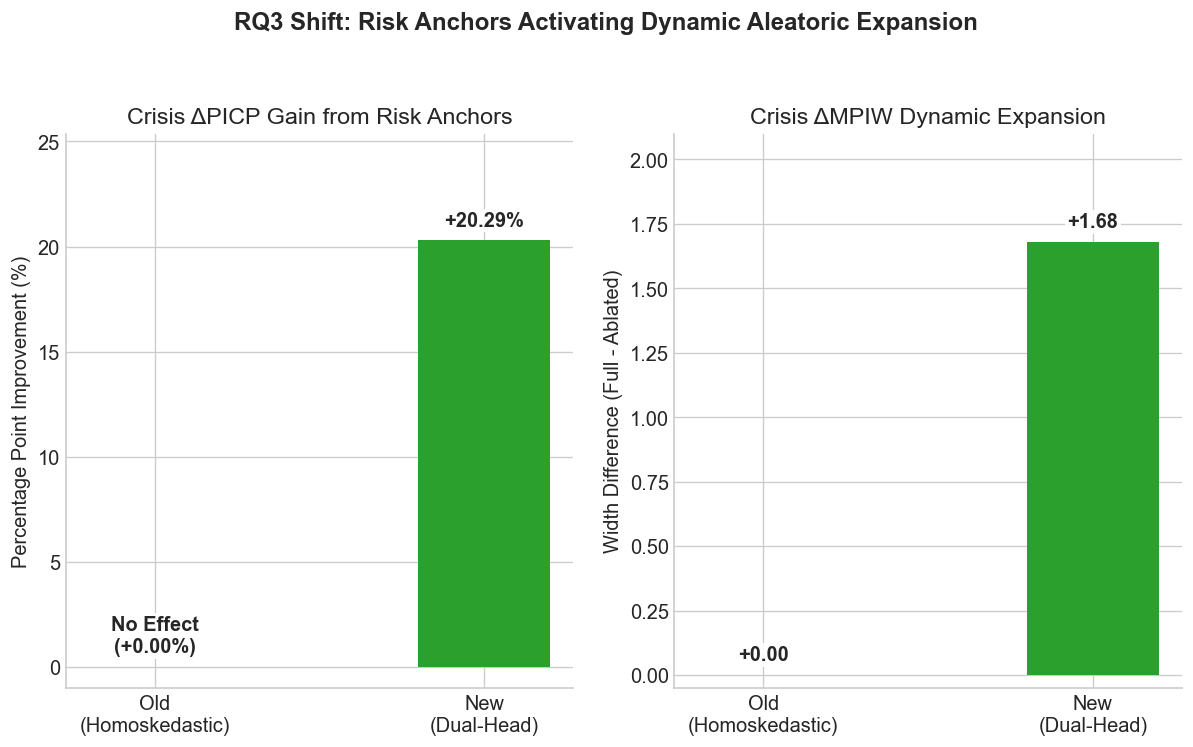

In [4]:
old_data = load_json("rq3_ablation_results_old.json")
new_data = load_json("rq3_ablation_results_2.json")

if old_data and new_data:
    old_delta_picp = (old_data["Model_3_Full"]["Crisis_Uncertainty"]["PICP"] - old_data["Model_3_Ablated"]["Crisis_Uncertainty"]["PICP"]) * 100
    new_delta_picp = (new_data["Model_3_Full"]["Crisis_Uncertainty"]["PICP"] - new_data["Model_3_Ablated"]["Crisis_Uncertainty"]["PICP"]) * 100

    old_delta_mpiw = old_data["Model_3_Full"]["Crisis_Uncertainty"]["MPIW"] - old_data["Model_3_Ablated"]["Crisis_Uncertainty"]["MPIW"]
    new_delta_mpiw = new_data["Model_3_Full"]["Crisis_Uncertainty"]["MPIW"] - new_data["Model_3_Ablated"]["Crisis_Uncertainty"]["MPIW"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    methods = ['Old\n(Homoskedastic)', 'New\n(Dual-Head)']
    bar_colors = [COLORS['old'], COLORS['new']]

    # --- Delta PICP Subplot ---
    bars1 = ax1.bar(methods, [old_delta_picp, new_delta_picp], color=bar_colors, width=0.4, zorder=3)
    ax1.set_title('Crisis ΔPICP Gain from Risk Anchors')
    ax1.set_ylabel('Percentage Point Improvement (%)')
    ax1.set_ylim(-1, max(old_delta_picp, new_delta_picp, 1.0) * 1.25)
    despine(ax1)
    
    for bar in bars1:
        h = bar.get_height()
        label = "No Effect\n(+0.00%)" if abs(h) < 1e-4 else f'+{h:.2f}%'
        y_pos = max(h, 0.5) if abs(h) < 1e-4 else h + 0.5
        ax1.text(bar.get_x() + bar.get_width()/2, y_pos, label, ha='center', va='bottom', fontweight='bold', bbox=text_bbox)

    # --- Delta MPIW Subplot ---
    bars2 = ax2.bar(methods, [old_delta_mpiw, new_delta_mpiw], color=bar_colors, width=0.4, zorder=3)
    ax2.set_title('Crisis ΔMPIW Dynamic Expansion')
    ax2.set_ylabel('Width Difference (Full - Ablated)')
    ax2.set_ylim(-0.05, max(old_delta_mpiw, new_delta_mpiw, 0.1) * 1.25)
    despine(ax2)
    
    for bar in bars2:
        h = bar.get_height()
        label = "No Effect\n(+0.00)" if abs(h) < 1e-4 else f'+{h:.2f}'
        y_pos = max(h, 0.05) if abs(h) < 1e-4 else h + 0.04
        ax2.text(bar.get_x() + bar.get_width()/2, y_pos, label, ha='center', va='bottom', fontweight='bold', bbox=text_bbox)

    plt.suptitle('RQ3 Shift: Risk Anchors Activating Dynamic Aleatoric Expansion', fontweight='bold', y=1.05)
    plt.savefig(viz_dir / "rq3_before_vs_after_clean.png", bbox_inches='tight')
    plt.show()

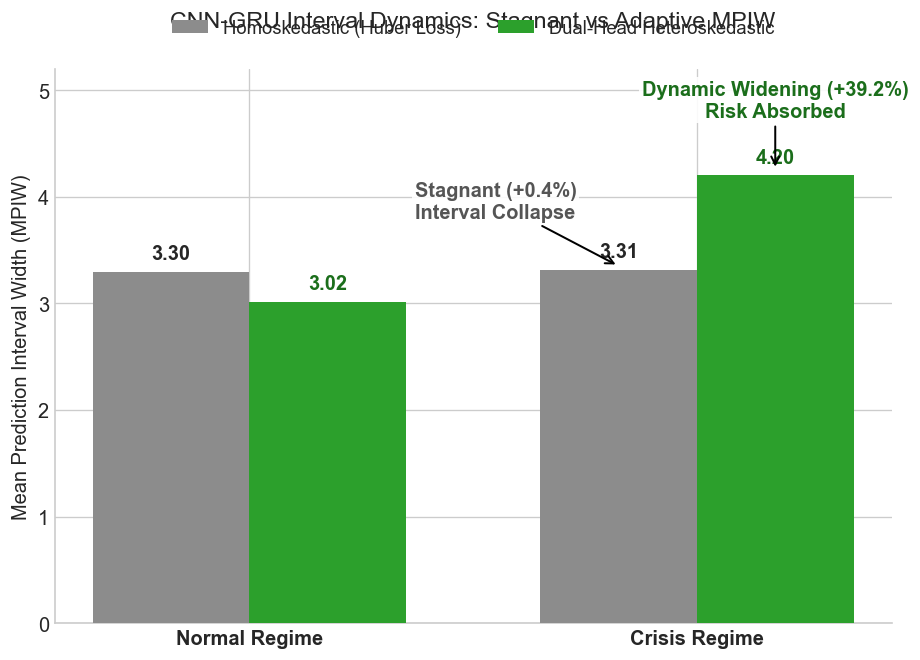

In [5]:
# ==============================================================================
# CELL: Visualizing MPIW Dynamics (Huber Loss vs Dual-Head)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

# Số liệu thực tế từ rq2_uncertainty_results.json và rq2_uncertainty_results_2.json
regimes = ['Normal Regime', 'Crisis Regime']
cnn_huber_mpiw = [3.2978, 3.3124]      # Huber Loss (Homoskedastic)
cnn_dualhead_mpiw = [3.0163, 4.1998]   # Dual-Head (Heteroskedastic)

x = np.arange(len(regimes))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

rects1 = ax.bar(x - width/2, cnn_huber_mpiw, width, 
                label='Homoskedastic (Huber Loss)', color='#8c8c8c', zorder=3)
rects2 = ax.bar(x + width/2, cnn_dualhead_mpiw, width, 
                label='Dual-Head Heteroskedastic', color='#2ca02c', zorder=3)

ax.set_ylabel('Mean Prediction Interval Width (MPIW)')
ax.set_title('CNN-GRU Interval Dynamics: Stagnant vs Adaptive MPIW', pad=25)
ax.set_xticks(x)
ax.set_xticklabels(regimes, fontweight='bold')
ax.set_ylim(0, 5.2)

# Đẩy legend lên trên
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Hiển thị số liệu và độ co giãn
text_box_props = dict(facecolor='white', edgecolor='none', alpha=0.9, pad=1.5)

for rect in rects1:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 0.08, f'{h:.2f}', 
            ha='center', va='bottom', fontweight='bold', bbox=text_box_props)

for rect in rects2:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 0.08, f'{h:.2f}', 
            ha='center', va='bottom', fontweight='bold', color='#1b6e1b', bbox=text_box_props)

# Thêm mũi tên / chú thích nhấn mạnh sự khác biệt
ax.annotate('Stagnant (+0.4%)\nInterval Collapse', 
            xy=(0.825, 3.35), xytext=(0.55, 3.8),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.2),
            fontweight='bold', color='#555555', ha='center', bbox=text_box_props)

ax.annotate('Dynamic Widening (+39.2%)\nRisk Absorbed', 
            xy=(1.175, 4.25), xytext=(1.175, 4.75),
            arrowprops=dict(facecolor='#2ca02c', arrowstyle='->', lw=1.2),
            fontweight='bold', color='#1b6e1b', ha='center', bbox=text_box_props)

plt.savefig(viz_dir / "mpiw_dynamics_comparison.png", bbox_inches='tight')
plt.show()

In [1]:
import sys
import torch
import numpy as np
import pandas as pd
from pathlib import Path

# 1. Setup đường dẫn
base_dir = Path.cwd() 
if base_dir.name == 'notebooks': 
    base_dir = base_dir.parent
sys.path.append(str(base_dir))

from src.data.dataset import prepare_dataloaders
from src.models.hybrid import CNN_GRU
from src.evaluation.mc_engine import run_stochastic_inference

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_file = base_dir / "data" / "processed" / "daily_processed_features.csv"

# 2. Xác định danh sách cột cho từng bậc Ablation (giống run_rq3_ablation.py)
df_sample = pd.read_csv(data_file, nrows=1, index_col='Date')
all_features = [c for c in df_sample.columns if c != 'Gold_Price_Return']

gvz_cols = [c for c in all_features if 'VIX' in c or 'GVZ' in c]
gpr_cols = [c for c in all_features if 'GPR' in c]
gold_cols = [c for c in all_features if 'Gold' in c and c not in gvz_cols]
macro_cols = [c for c in all_features if c not in gvz_cols and c not in gpr_cols and c not in gold_cols]

m0_features = gold_cols if len(gold_cols) > 0 else [all_features[0]]
m1_features = list(dict.fromkeys(m0_features + macro_cols))
m2_features = list(dict.fromkeys(m1_features + gvz_cols))
m3_features = list(dict.fromkeys(m1_features + gpr_cols))
m4_features = all_features

# 3. Khôi phục nhãn y_test thực tế và mảng is_crisis
dataloaders_full, raw_arrays_full, scaler_full = prepare_dataloaders(str(data_file), target_col="Gold_Price_Return")
s_y = scaler_full.scale_[0]
m_y = scaler_full.mean_[0]
y_test = (raw_arrays_full['y_test'] * s_y) + m_y

df = pd.read_csv(data_file, index_col='Date', parse_dates=True)
train_gvz = df.loc[df.index <= '2021-12-31', 'Gold_VIX_Level']
gvz_threshold = train_gvz.quantile(0.90)

test_gvz = df.loc[df.index > '2023-12-29', 'Gold_VIX_Level']
# Căn chỉnh sliding window theo số mẫu thực tế của test set
is_crisis = test_gvz.iloc[-len(y_test):].values > gvz_threshold

# 4. Hàm chạy suy luận tương thích từng bộ đặc trưng
def get_predictions(model_name: str, keep_features: list):
    print(f"\nRunning inference for {model_name} (Input features: {len(keep_features)})...")
    
    # Chuẩn bị dataloader riêng với đúng số lượng features
    dl, _, scaler_m = prepare_dataloaders(
        str(data_file), 
        target_col="Gold_Price_Return", 
        keep_cols=keep_features
    )
    
    sample_x, _ = next(iter(dl['train']))
    input_size = sample_x.shape[2]
    
    model = CNN_GRU(input_size=input_size).to(device)
    model_path = base_dir / "models_saved" / f"{model_name}_best.pt"
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    y_mean, lower, upper, _ = run_stochastic_inference(
        model=model, 
        dataloader=dl['test'], 
        device=device, 
        scaler_target=scaler_m, 
        T=100,  # Dùng T=100 hoặc T=200 tuỳ nhu cầu tốc độ
        confidence_level=0.90
    )
    return y_mean, lower, upper

# 5. Thực thi trích xuất dải bất định
y_mean_M0, lower_M0, upper_M0 = get_predictions("M0_GoldOnly", m0_features)
y_mean_M2, lower_M2, upper_M2 = get_predictions("M2_Macro_GVZ", m2_features)
y_mean_M3, lower_M3, upper_M3 = get_predictions("M3_Macro_GPR", m3_features)
y_mean_full, lower_full, upper_full = get_predictions("M4_Full", m4_features)

# Tính toán mảng độ rộng (Width) cho Sharpness Diagram
width_M0_crisis = (upper_M0 - lower_M0)[is_crisis]
width_M2_crisis = (upper_M2 - lower_M2)[is_crisis]
width_M3_crisis = (upper_M3 - lower_M3)[is_crisis]
width_full_crisis = (upper_full - lower_full)[is_crisis]

print("\nKhôi phục thành công toàn bộ dải rủi ro cho M0, M2, M3, M4!")

Data Split Summary:
- Train : 2008-06-04 to 2021-12-31 | Rows: 3417
- Val   : 2022-01-03 to 2023-12-29 | Rows: 501
- Test  : 2024-01-02 to 2026-09-11 | Rows: 678

Tensor Shapes:
- X_train: (3396, 21, 13), y_train: (3396,)
- X_val  : (501, 21, 13), y_val: (501,)
- X_test : (678, 21, 13), y_test: (678,)

Running inference for M0_GoldOnly (Input features: 1)...
Data Split Summary:
- Train : 2008-06-04 to 2021-12-31 | Rows: 3417
- Val   : 2022-01-03 to 2023-12-29 | Rows: 501
- Test  : 2024-01-02 to 2026-09-11 | Rows: 678

Tensor Shapes:
- X_train: (3396, 21, 2), y_train: (3396,)
- X_val  : (501, 21, 2), y_val: (501,)
- X_test : (678, 21, 2), y_test: (678,)


C:\Users\huy\AppData\Local\Temp\ipykernel_7932\3744591377.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=devi


Running inference for M2_Macro_GVZ (Input features: 10)...
Data Split Summary:
- Train : 2008-06-04 to 2021-12-31 | Rows: 3417
- Val   : 2022-01-03 to 2023-12-29 | Rows: 501
- Test  : 2024-01-02 to 2026-09-11 | Rows: 678

Tensor Shapes:
- X_train: (3396, 21, 11), y_train: (3396,)
- X_val  : (501, 21, 11), y_val: (501,)
- X_test : (678, 21, 11), y_test: (678,)


C:\Users\huy\AppData\Local\Temp\ipykernel_7932\3744591377.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=devi


Running inference for M3_Macro_GPR (Input features: 10)...
Data Split Summary:
- Train : 2008-06-04 to 2021-12-31 | Rows: 3417
- Val   : 2022-01-03 to 2023-12-29 | Rows: 501
- Test  : 2024-01-02 to 2026-09-11 | Rows: 678

Tensor Shapes:
- X_train: (3396, 21, 11), y_train: (3396,)
- X_val  : (501, 21, 11), y_val: (501,)
- X_test : (678, 21, 11), y_test: (678,)


C:\Users\huy\AppData\Local\Temp\ipykernel_7932\3744591377.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=devi


Running inference for M4_Full (Input features: 12)...
Data Split Summary:
- Train : 2008-06-04 to 2021-12-31 | Rows: 3417
- Val   : 2022-01-03 to 2023-12-29 | Rows: 501
- Test  : 2024-01-02 to 2026-09-11 | Rows: 678

Tensor Shapes:
- X_train: (3396, 21, 13), y_train: (3396,)
- X_val  : (501, 21, 13), y_val: (501,)
- X_test : (678, 21, 13), y_test: (678,)


C:\Users\huy\AppData\Local\Temp\ipykernel_7932\3744591377.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=devi


Khôi phục thành công toàn bộ dải rủi ro cho M0, M2, M3, M4!


In [3]:
import numpy as np

# 1. Tính toán độ lệch chuẩn tổng hợp (y_std) từ dải băng 90% đã có
Z_90 = 1.6448536269514722
y_std_full = (upper_full - lower_full) / (2 * Z_90)
y_std_M2 = (upper_M2 - lower_M2) / (2 * Z_90)
y_std_M0 = (upper_M0 - lower_M0) / (2 * Z_90)
y_std_M3 = (upper_M3 - lower_M3) / (2 * Z_90)

print(f"y_std_full shape: {y_std_full.shape} | Mean estimated std: {y_std_full.mean():.4f}")

y_std_full shape: (678,) | Mean estimated std: 0.0195


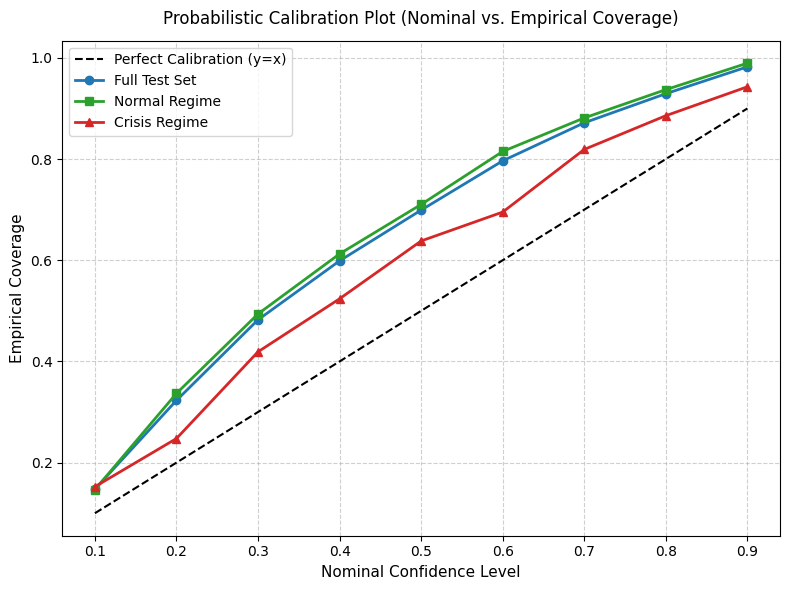

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def compute_empirical_coverage(y_true, y_mean, y_std, nominal_levels):
    coverages = []
    for level in nominal_levels:
        # Tính critical value z hai phía cho từng mức nominal (vd: 0.10 -> 0.90)
        z = norm.ppf(0.5 + level / 2.0)
        lower = y_mean - z * y_std
        upper = y_mean + z * y_std
        coverage = np.mean((y_true >= lower) & (y_true <= upper))
        coverages.append(coverage)
    return coverages

nominal_levels = np.arange(0.1, 1.0, 0.1)

# Sử dụng mô hình M4_Full (hoặc đổi thành y_mean_M2, y_std_M2 nếu vẽ cho M2)
cov_full = compute_empirical_coverage(y_test, y_mean_full, y_std_full, nominal_levels)
cov_normal = compute_empirical_coverage(y_test[~is_crisis], y_mean_full[~is_crisis], y_std_full[~is_crisis], nominal_levels)
cov_crisis = compute_empirical_coverage(y_test[is_crisis], y_mean_full[is_crisis], y_std_full[is_crisis], nominal_levels)

plt.figure(figsize=(8, 6))
plt.plot(nominal_levels, nominal_levels, 'k--', label='Perfect Calibration (y=x)', linewidth=1.5)
plt.plot(nominal_levels, cov_full, 'o-', color='#1f77b4', label='Full Test Set', linewidth=2)
plt.plot(nominal_levels, cov_normal, 's-', color='#2ca02c', label='Normal Regime', linewidth=2)
plt.plot(nominal_levels, cov_crisis, '^-', color='#d62728', label='Crisis Regime', linewidth=2)

plt.title('Probabilistic Calibration Plot (Nominal vs. Empirical Coverage)', fontsize=12, pad=12)
plt.xlabel('Nominal Confidence Level', fontsize=11)
plt.ylabel('Empirical Coverage', fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('calibration_plot.png', dpi=300)
plt.show()

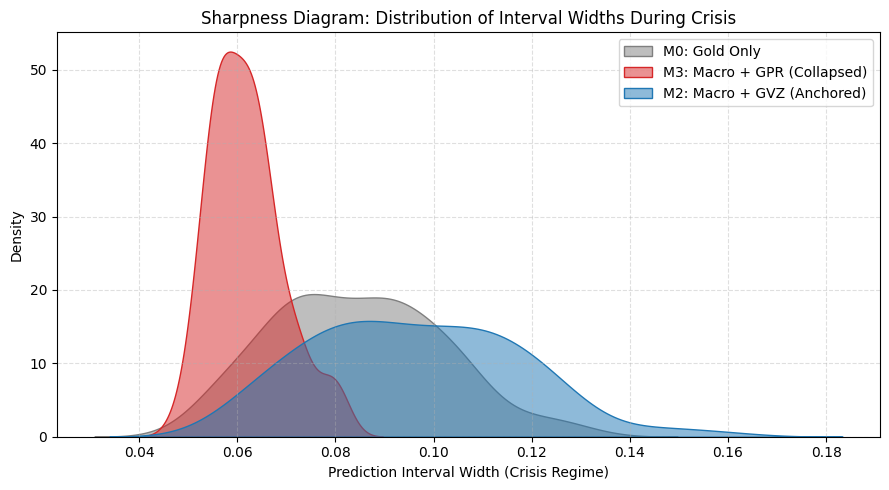

In [5]:
import seaborn as sns

# Giả định: mảng độ rộng (upper - lower) tại chế độ Crisis
# width_M0_crisis, width_M2_crisis, width_M3_crisis

plt.figure(figsize=(9, 5))
sns.kdeplot(width_M0_crisis, fill=True, color='#7f7f7f', label='M0: Gold Only', alpha=0.5)
sns.kdeplot(width_M3_crisis, fill=True, color='#d62728', label='M3: Macro + GPR (Collapsed)', alpha=0.5)
sns.kdeplot(width_M2_crisis, fill=True, color='#1f77b4', label='M2: Macro + GVZ (Anchored)', alpha=0.5)

plt.title('Sharpness Diagram: Distribution of Interval Widths During Crisis')
plt.xlabel('Prediction Interval Width (Crisis Regime)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('sharpness_diagram.png', dpi=300)
plt.show()

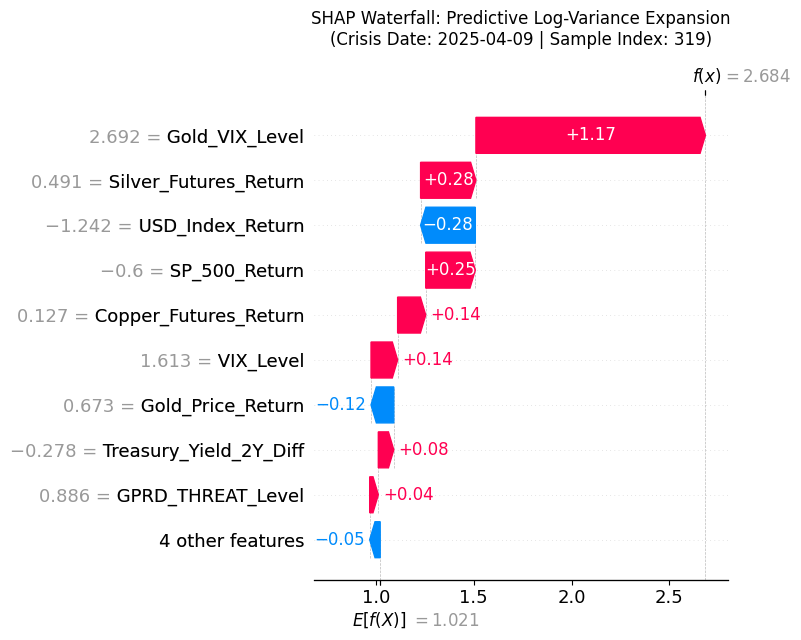

In [9]:
import sys
import shap
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Thiết lập đường dẫn
base_dir = Path.cwd()
if base_dir.name == 'notebooks':
    base_dir = base_dir.parent
sys.path.append(str(base_dir))

from src.data.dataset import prepare_dataloaders
from src.models.hybrid import CNN_GRU

# 2. Sử dụng CPU để tránh triệt để lỗi "cudnn RNN backward"
eval_device = torch.device("cpu")
data_file = base_dir / "data" / "processed" / "daily_processed_features.csv"

if 'raw_arrays' not in globals():
    dataloaders, raw_arrays, scaler = prepare_dataloaders(str(data_file), target_col="Gold_Price_Return")
    test_dates = raw_arrays['test_dates']

# 3. Wrapper trích xuất Variance Head
class VarianceHeadWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        output = self.base_model(x)
        if isinstance(output, tuple):
            return output[1]  # logvar head
        elif isinstance(output, dict):
            return output['logvar']
        return output

# 4. Tải model M4_Full lên CPU
model_m4 = CNN_GRU(input_size=13).to(eval_device)
model_path = base_dir / "models_saved" / "M4_Full_best.pt"
model_m4.load_state_dict(torch.load(model_path, map_location=eval_device, weights_only=True))

# QUAN TRỌNG: Để chế độ train(True) nhưng tắt dropout để gradient của RNN chạy hợp lệ
model_m4.train(True)
for m in model_m4.modules():
    if isinstance(m, nn.Dropout):
        m.p = 0.0  # Vô hiệu hóa dropout trong lúc tính gradient SHAP

var_model = VarianceHeadWrapper(model_m4).to(eval_device)

# 5. Tên các đặc trưng
df_proc = pd.read_csv(data_file, index_col='Date', parse_dates=True)
feature_names = [c for c in df_proc.columns if c != 'Gold_Price_Return'] + ['Gold_Price_Return']

# 6. Chuẩn bị background và sample trên CPU
np.random.seed(42)
bg_indices = np.random.choice(len(raw_arrays['X_train']), size=100, replace=False)
background_tensor = torch.tensor(raw_arrays['X_train'][bg_indices], dtype=torch.float32).to(eval_device)

gvz_col_idx = feature_names.index('Gold_VIX_Level')
crisis_sample_idx = int(np.argmax(raw_arrays['X_test'][:, -1, gvz_col_idx]))
crisis_date = pd.to_datetime(test_dates[crisis_sample_idx]).strftime('%Y-%m-%d')

test_sample = torch.tensor(raw_arrays['X_test'][crisis_sample_idx:crisis_sample_idx+1], dtype=torch.float32).to(eval_device)

# 7. Tính SHAP với GradientExplainer trên CPU
explainer = shap.GradientExplainer(var_model, background_tensor)
shap_values = explainer.shap_values(test_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

# shap_values gốc có dạng: (1, 21, 13) hoặc (1, 21, 13, 1)
# Gộp qua 21 timesteps và ép về đúng 1D vector (13,)
shap_per_feature = np.sum(shap_values[0], axis=0).squeeze()

# Ép giá trị feature thực tế của sample về đúng 1D vector (13,)
sample_values = raw_arrays['X_test'][crisis_sample_idx, -1, :].squeeze()

# 8. Tính base_value dạng float vô hướng (scalar)
with torch.no_grad():
    base_val = float(var_model(background_tensor).mean().item())

# Kiểm tra shape trước khi vẽ (đảm bảo cả hai đều là (13,))
assert shap_per_feature.shape == (13,), f"Shape lỗi: {shap_per_feature.shape}, cần là (13,)"
assert sample_values.shape == (13,), f"Shape lỗi: {sample_values.shape}, cần là (13,)"

# 9. Tạo đối tượng Explanation và vẽ Waterfall Plot
explanation = shap.Explanation(
    values=shap_per_feature,
    base_values=base_val,
    data=sample_values,
    feature_names=feature_names
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, max_display=10, show=False)
plt.title(f"SHAP Waterfall: Predictive Log-Variance Expansion\n(Crisis Date: {crisis_date} | Sample Index: {crisis_sample_idx})", fontsize=12, pad=15)
plt.tight_layout()

save_path = base_dir / "results" / "shap_waterfall_crisis.png"
save_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

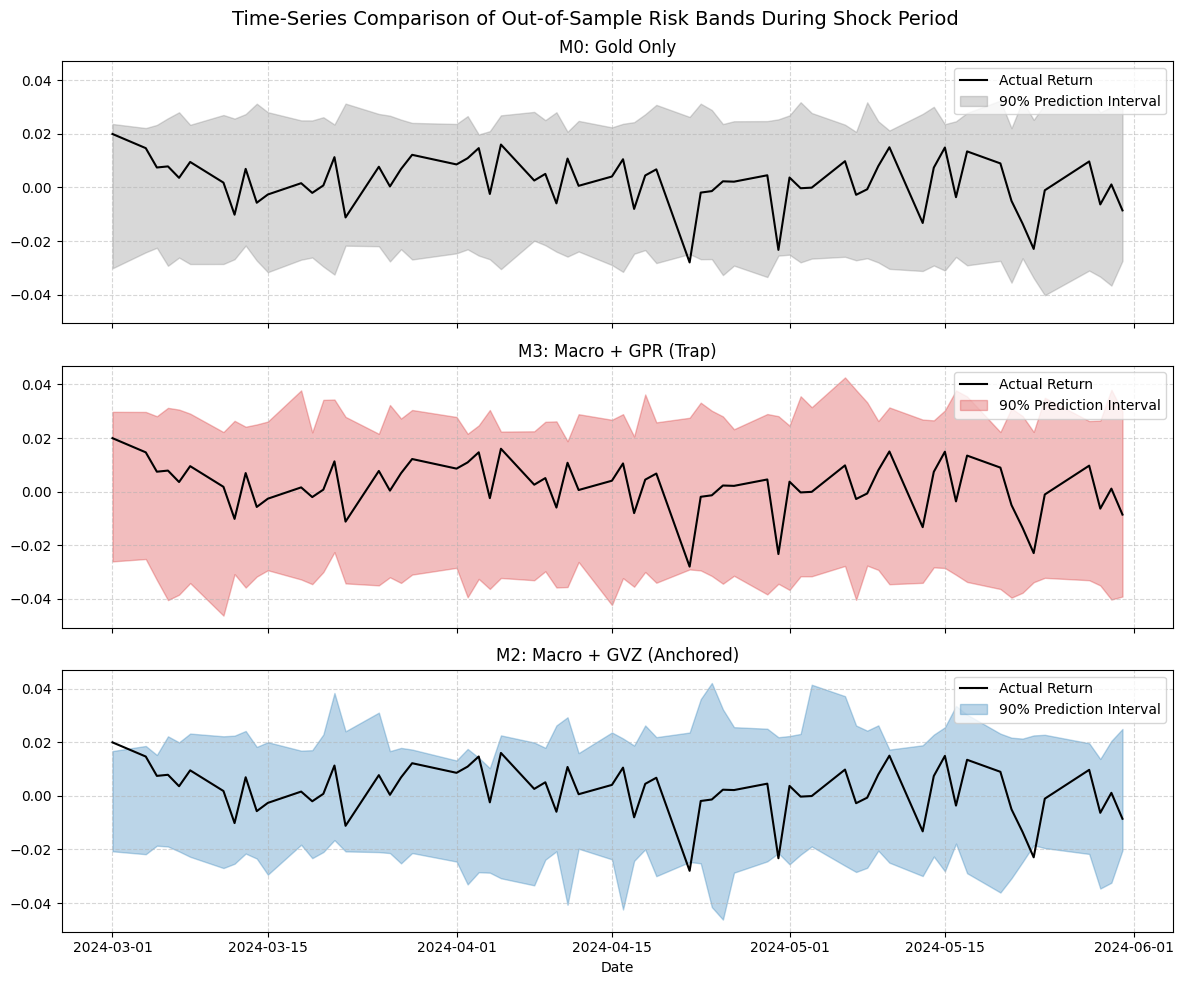

In [10]:
import pandas as pd

# Giả định: test_dates là mảng datetime, các mảng y_test, lower/upper của các mô hình
# Lấy index của một khoảng thời gian cụ thể (ví dụ: tháng 3 - tháng 5 năm 2024)
start_date = pd.to_datetime('2024-03-01')
end_date = pd.to_datetime('2024-05-31')
mask = (test_dates >= start_date) & (test_dates <= end_date)

dates_window = test_dates[mask]
y_true_window = y_test[mask]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, sharey=True)

models_data = [
    ('M0: Gold Only', lower_M0, upper_M0, '#7f7f7f'),
    ('M3: Macro + GPR (Trap)', lower_M3, upper_M3, '#d62728'),
    ('M2: Macro + GVZ (Anchored)', lower_M2, upper_M2, '#1f77b4')
]

for i, (name, lower, upper, color) in enumerate(models_data):
    axes[i].plot(dates_window, y_true_window, color='black', linewidth=1.5, label='Actual Return')
    axes[i].fill_between(dates_window, lower[mask], upper[mask], color=color, alpha=0.3, label='90% Prediction Interval')
    axes[i].set_title(name)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].legend(loc='upper right')

plt.xlabel('Date')
fig.suptitle('Time-Series Comparison of Out-of-Sample Risk Bands During Shock Period', y=0.98, fontsize=14)
plt.tight_layout()
plt.savefig('timeseries_risk_bands.png', dpi=300)
plt.show()